# 04 · Обучение и сравнение моделей

**Зачем этот шаг.** Обучаем модели, которые по прошлому технологии оценивают
вероятность того, что сейчас она — слабый сигнал, и честно сравниваем их на
технологиях, которых модели не видели.

**Три модели на одной выборке** (`src/lctrend/modeling/training/pipeline.py`):

1. **CatBoost** — градиентный бустинг по таблице: признаки технологии на дату T
   и агрегаты её соседей. Быстрый, устойчивый на малых данных, хорошо
   объясняется. Это наша планка.
2. **HGT** — графовая нейросеть: смотрит на само окружение технологии (её
   документы, соседние технологии, организации) и учится, какие связи важны.
3. **Стекинг HGT → CatBoost** — CatBoost получает ещё один признак: вероятность
   от HGT. Чтобы не было подсказки, для обучающих строк эта вероятность
   считается **out-of-fold**: выборку делят на 5 частей, HGT обучают на четырёх и
   предсказывают пятую — так ни одна строка не получает оценку от модели,
   которая видела её ответ.

**Правила честной проверки.** Температура (калибровка вероятностей) и порог
«сигнал/не сигнал» подбираются на valid; test используется только для отчёта.
Лучшая модель выбирается по PR-AUC на valid — правило зафиксировано до того,
как мы смотрим на test.

**Словарь метрик**

| Метрика | Что показывает |
|---|---|
| **PR-AUC** | насколько хорошо модель ставит настоящие слабые сигналы выше остальных; главная метрика при редком классе. Случайная модель получает PR-AUC, равную доле класса 1 |
| **ROC-AUC** | вероятность, что случайный сигнал оценён выше случайного не-сигнала; 0,5 — случайно |
| **precision / recall / F1** | при выбранном пороге: какая доля названных сигналов верна / какую долю сигналов нашли / их среднее |
| **95% ДИ по семьям** | разброс PR-AUC при пересэмплировании семейств: чем шире, тем меньше доверия цифре |
| **калибровка** | совпадает ли «вероятность 0,8» с тем, что 80% таких технологий — действительно сигналы |

**Где мы в цепочке**

1. **01 · выгрузка** — что есть в графе на каждую дату (признаки и окружение технологий);
2. **02 · разметка** — что LLM считает слабым сигналом в каждый год;
3. **03 · выборка** — соединяем 01 и 02 в обучающую таблицу;
4. **04 · обучение** — CatBoost, HGT и их комбинация, метрики;
5. **05 · граф** — записываем итоговую разметку в узлы технологий.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from lab import *
from IPython.display import display, Markdown

from lctrend.modeling.dataset.builder import build_dataset
from lctrend.modeling.training.pipeline import train_pipeline

# Выборку собирает ноутбук 03. Если его ещё не запускали, собираем тем же кодом здесь.
if not (DATASET_DIR / "dataset.json").exists():
    display(Markdown("Обучающей выборки ещё нет — собираю её (как в 03), это займёт около минуты…"))
    build_dataset(CONFIG)
dataset = json.loads((DATASET_DIR / "dataset.json").read_text(encoding="utf-8"))
# Обучение займёт несколько минут. Уже обученные модели не переобучаются,
# пока не удалите models/report.json или не поставите RETRAIN = True.
RETRAIN = not (MODELS_DIR / "report.json").exists()
if RETRAIN:
    train_pipeline(CONFIG)
report = json.loads((MODELS_DIR / "report.json").read_text(encoding="utf-8"))
parts = pd.DataFrame({"строк": report["rows"], "семейств со слабым сигналом": report["positive_families"]})
display(parts.rename_axis("часть"))

C:\tema\Code\hackathons\хакатон\анализ трендов\LCTrendSearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\tema\Code\hackathons\хакатон\анализ трендов\LCTrendSearch\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


,строк,семейств со слабым сигналом
часть,,
train,5300,248
valid,1116,59
test,1336,44


## 1. Метрики на valid и test

**Как читать.** Сравнивайте PR-AUC со столбцом «PR-AUC случайной модели»:
только превышение над ним — заслуга модели. Смотрите на ширину
доверительного интервала: если интервалы моделей перекрываются, разница
между ними может быть случайной.

In [2]:
NAME = {"catboost": "CatBoost", "hgt": "HGT", "stacked": "стекинг HGT → CatBoost"}
table = []
for name, model in report["models"].items():
    for part in ("valid", "test"):
        m = model["metrics"].get(part, {})
        at = m.get("at_valid_f1_threshold", {})
        ci = m.get("pr_auc_family_ci95")
        table.append({"модель": NAME.get(name, name), "часть": part, "PR-AUC": m.get("pr_auc"),
                      "95% ДИ": f"{ci[0]:.2f}–{ci[1]:.2f}" if ci else "—",
                      "PR-AUC случайной модели": m.get("positive_rate"), "ROC-AUC": m.get("roc_auc"),
                      "precision": at.get("precision"), "recall": at.get("recall"), "F1": at.get("f1"),
                      "порог": at.get("threshold")})
display(pd.DataFrame(table).set_index(["модель", "часть"]).round(3))
winner = report["winner"]["model"]
display(Markdown(f"**Лучшая модель по PR-AUC на valid: {NAME.get(winner, winner)}.**"))

PR-AUC     95% ДИ  PR-AUC случайной модели  ROC-AUC  precision  recall     F1  порог
модель                 часть                                                                                      
CatBoost               valid   0.364  0.24–0.49                    0.172    0.692      0.365   0.474  0.413  0.476
                       test    0.242  0.16–0.39                    0.108    0.730      0.237   0.417  0.302  0.476
HGT                    valid   0.370  0.25–0.49                    0.172    0.718      0.414   0.438  0.425  0.619
                       test    0.251  0.16–0.40                    0.108    0.720      0.211   0.361  0.267  0.619
стекинг HGT → CatBoost valid   0.393  0.27–0.53                    0.172    0.706      0.399   0.432  0.415  0.537
                       test    0.262  0.16–0.41                    0.108    0.693      0.257   0.465  0.331  0.537

**Лучшая модель по PR-AUC на valid: стекинг HGT → CatBoost.**

## 2. Точность и полнота на test

**Как читать.** Кривая показывает цену полноты: чтобы найти больше сигналов
(правее), приходится мириться с большей долей ошибок (ниже). Чем выше кривая —
тем лучше; пунктир — уровень случайной модели.

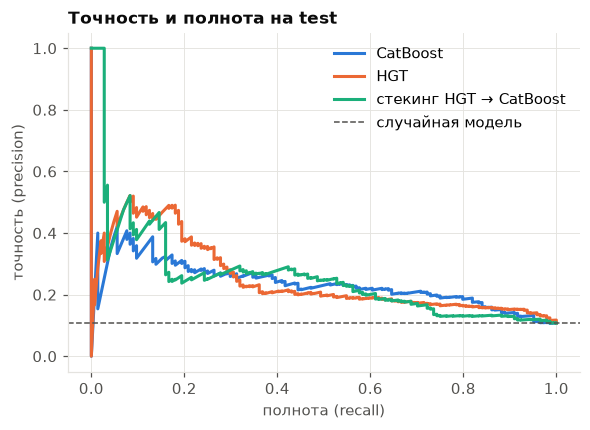

In [3]:
from sklearn.metrics import precision_recall_curve

predictions = read(MODELS_DIR / "predictions.csv")
test = predictions[predictions.split == "test"]
fig, ax = plt.subplots(figsize=(6, 4))
for name in report["models"]:
    column = f"p_{name}"
    part = test.dropna(subset=[column])
    precision, recall, _ = precision_recall_curve(part.label, part[column])
    ax.plot(recall, precision, label=NAME.get(name, name))
ax.axhline(test.label.mean(), color=MUTED, linewidth=1, linestyle="--", label="случайная модель")
ax.set_xlabel("полнота (recall)")
ax.set_ylabel("точность (precision)")
ax.set_title("Точность и полнота на test")
ax.legend()
plt.show()

## 3. Калибровка лучшей модели

**Зачем.** ТЗ требует «уверенность модели больше 75%». Это имеет смысл, только
если вероятность честная: среди технологий с оценкой 0,8 примерно 80% должны
оказаться сигналами.

**Как читать.** Точки на пунктирной диагонали — вероятности честные; выше
диагонали — модель недооценивает, ниже — переоценивает.

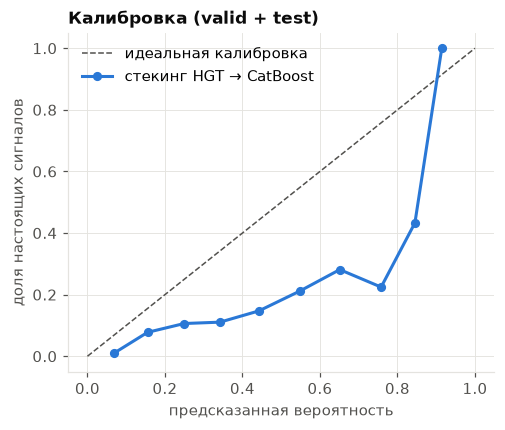

,средняя вероятность,доля сигналов,строк
корзина,,,
"(-0.001, 0.1]",0.067,0.009,223
"(0.1, 0.2]",0.155,0.078,438
"(0.2, 0.3]",0.250,0.106,593
"(0.3, 0.4]",0.342,0.111,479
"(0.4, 0.5]",0.442,0.147,197
"(0.5, 0.6]",0.548,0.212,137
"(0.6, 0.7]",0.651,0.281,96
"(0.7, 0.8]",0.758,0.224,147
"(0.8, 0.9]",0.845,0.433,134


In [4]:
column = f"p_{winner}"
part = predictions.dropna(subset=[column])
part = part.assign(bin=pd.cut(part[column], [i / 10 for i in range(11)], include_lowest=True))
reliability = part.groupby("bin", observed=True).agg(predicted=(column, "mean"), observed=("label", "mean"), rows=("label", "size"))
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--", label="идеальная калибровка")
ax.plot(reliability.predicted, reliability.observed, marker="o", markersize=5, label=NAME.get(winner, winner))
ax.set_xlabel("предсказанная вероятность")
ax.set_ylabel("доля настоящих сигналов")
ax.set_title("Калибровка (valid + test)")
ax.legend()
plt.show()
display(reliability.rename(columns={"predicted": "средняя вероятность", "observed": "доля сигналов",
                                    "rows": "строк"}).rename_axis("корзина").round(3))

## 4. На что опирается CatBoost

**Как читать.** Важность — насколько признак в среднем меняет предсказания.
Это ответ на вопрос «по каким признакам технология отнесена к сигналу» из
ТЗ — на уровне всей модели. Для стекинга отдельно показано, насколько важен
вклад HGT.

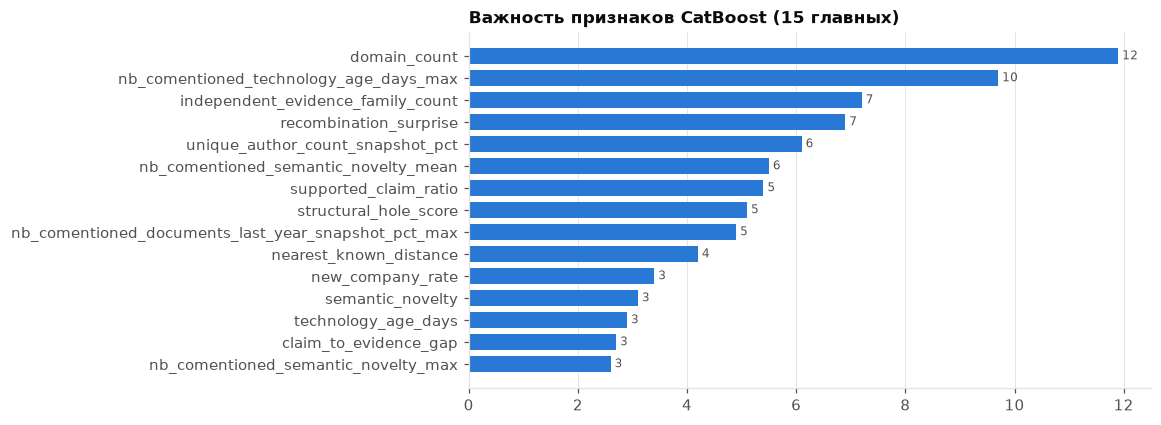

**Вклад HGT в стекинге:** важность 24.9, место 1 из 95 признаков.

In [5]:
importance = pd.Series(report["models"]["catboost"]["importance"]).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 4.2))
bar(ax, importance.index, importance.values.round(1), horizontal=True)
ax.set_title("Важность признаков CatBoost (15 главных)")
plt.show()
if "stacked" in report["models"]:
    s = report["models"]["stacked"]
    display(Markdown(
        f"**Вклад HGT в стекинге:** важность {s['hgt_feature_importance']:.1f}, "
        f"место {s['hgt_feature_rank']} из {len(s['features'])} признаков."
    ))

## 5. Объяснение одной оценки

**Зачем.** Для карточки технологии нужно объяснить конкретную оценку: какие её
признаки подняли вероятность, какие опустили.

**Как читать.** SHAP — вклад признака в оценку модели (плюс — к сигналу, минус —
от сигнала). Последний столбец — на сколько процентных пунктов изменится
вероятность, если значение признака заменить на типичное (медиану train). Это
сравнение внутри модели, а не причинная связь.

In [6]:
from catboost import CatBoostClassifier
from lctrend.modeling.training.catboost_model import explain_catboost

scores = read(LABELING_DIR / "scores.csv")
scoring_rows = read(DATASET_DIR / "scoring.csv", dtype=str).fillna("")
top = scores.dropna(subset=["p_catboost"]).sort_values("p_catboost", ascending=False).iloc[0]
row = scoring_rows[scoring_rows.technology_id == top.technology_id].iloc[0].to_dict()
model = CatBoostClassifier()
model.load_model(str(MODELS_DIR / "catboost.cbm"))
explanation = explain_catboost(model, row, report["models"]["catboost"], top_k=10)
display(Markdown(f"**{top.technology}** — вероятность слабого сигнала по CatBoost {explanation['probability']:.0%}."))
display(pd.DataFrame(explanation["features"])[["feature", "value", "train_median", "shap_logit",
                                               "probability_point_difference_vs_train_median"]]
        .rename(columns={"feature": "признак", "value": "значение", "train_median": "типичное (медиана train)",
                         "shap_logit": "вклад SHAP",
                         "probability_point_difference_vs_train_median": "изменение вероятности, п.п."})
        .round(3).style.hide(axis="index"))

**Framework for LLM and source code security testing** — вероятность слабого сигнала по CatBoost 96%.

признак,значение,типичное (медиана train),вклад SHAP,"изменение вероятности, п.п."
domain_count,1.000000,3.000000,0.295000,16.951000
nb_comentioned_technology_age_days_max,nan,1737.000000,0.175000,8.275000
independent_evidence_family_count,1.000000,0.000000,0.171000,7.398000
supported_claim_ratio,1.000000,1.000000,0.111000,0.000000
claim_to_evidence_gap,1.099000,0.000000,0.099000,2.410000
nb_comentioned_semantic_novelty_mean,nan,0.141000,0.094000,2.746000
nb_comentioned_documents_last_year_snapshot_pct_max,nan,0.991000,0.094000,2.442000
recombination_surprise,nan,5.644000,0.067000,3.802000
unique_author_count_snapshot_pct,0.789000,0.744000,0.064000,0.000000
new_company_rate,nan,1.000000,-0.052000,-1.706000


## 6. Итоговая разметка всех технологий

**Что это.** Лучшая модель оценивает каждую технологию на её последнюю дату
(`labeling/scores.csv`). Рядом — вердикт LLM для сверки. «Не технологии»
исключены. Следующий шаг (**05**) запишет это в граф.

С вероятностью слабого сигнала ≥ 75%: **11** технологий из 1 822.

технология,дата,итоговая вероятность,CatBoost,HGT,стекинг,вердикт LLM
ACE (Abstract-Concrete-Execute) Security Architecture,2026-09-29,0.925000,0.836000,0.828000,0.925000,unclear
PropertyGPT,2026-09-29,0.879000,0.937000,0.677000,0.879000,unclear
Lattice-based Attribute-Based Encryption (ABE),2026-09-29,0.868000,0.944000,0.748000,0.868000,niche
Hybrid cybersecurity framework for IoE integrating FL and LLMs,2026-09-29,0.853000,0.785000,0.538000,0.853000,unclear
Confucius framework,2026-09-29,0.847000,0.632000,0.606000,0.847000,unclear
Agent Laboratory,2026-09-29,0.818000,0.758000,0.575000,0.818000,unclear
EukPhylo (EukPhylogenomics),2026-09-29,0.804000,0.660000,0.810000,0.804000,unclear
AI-driven exploit generation,2026-09-29,0.802000,0.665000,0.519000,0.802000,success
AgentHarm,2026-09-29,0.798000,0.668000,0.652000,0.798000,niche
Hybrid RIS-aided Digital AirComp (HRD-AirComp),2026-09-29,0.778000,0.737000,0.819000,0.778000,unclear


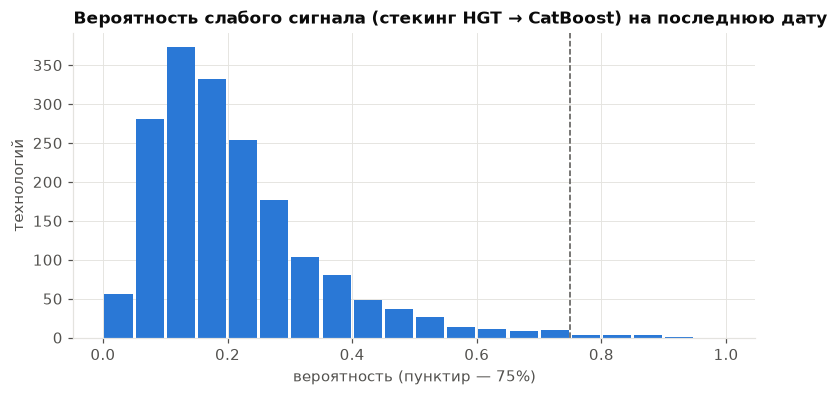

In [7]:
answers = read_jsonl(DATASET_DIR / "llm_labels.csv.jsonl")
answers = answers[answers.status == "ok"].drop_duplicates("technology_id", keep="last")[["technology_id", "verdict", "is_technology"]]
final = scores.merge(answers, on="technology_id", how="left")
final = final[final.is_technology.fillna(True).astype(bool)]
display(Markdown(f"С вероятностью слабого сигнала ≥ 75%: **{num((final.probability >= 0.75).sum())}** технологий из {num(len(final))}."))
display(final.sort_values("probability", ascending=False).head(15)[
    ["technology", "snapshot_date", "probability", "p_catboost", "p_hgt", "p_stacked", "verdict"]]
    .rename(columns={"technology": "технология", "snapshot_date": "дата", "probability": "итоговая вероятность",
                     "p_catboost": "CatBoost", "p_hgt": "HGT", "p_stacked": "стекинг", "verdict": "вердикт LLM"})
    .round(3).style.hide(axis="index"))
fig, ax = plt.subplots()
ax.hist(final.probability.dropna(), bins=[i / 20 for i in range(21)], color=BLUE, rwidth=0.9)
ax.axvline(0.75, color=MUTED, linewidth=1, linestyle="--")
ax.set_title(f"Вероятность слабого сигнала ({NAME.get(winner, winner)}) на последнюю дату")
ax.set_xlabel("вероятность (пунктир — 75%)")
ax.set_ylabel("технологий")
plt.show()